In [1]:

import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Import our feature extraction utilities
import sys
sys.path.append('..')
from utils.feature_utils import extract_all_features

In [3]:

# Set paths
PROCESSED_DATA_DIR = '../data/processed'

# Load preprocessed data
print("Loading preprocessed data...")
X_train = np.load(os.path.join(PROCESSED_DATA_DIR, 'X_train.npy'))
X_test = np.load(os.path.join(PROCESSED_DATA_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(PROCESSED_DATA_DIR, 'y_train.npy'))
y_test = np.load(os.path.join(PROCESSED_DATA_DIR, 'y_test.npy'))

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Loading preprocessed data...
Training data shape: (5712, 224, 224, 3)
Test data shape: (1311, 224, 224, 3)


In [4]:
def extract_features_from_dataset(images):
    """Extract features from a dataset of images"""
    features_list = []
    
    for img in tqdm(images, desc='Extracting features'):
        # Convert to uint8 for feature extraction
        img_uint8 = (img * 255).astype(np.uint8)
        features = extract_all_features(img_uint8)
        features_list.append(features)
    
    return pd.DataFrame(features_list)

# Extract features from training set
print("\nExtracting features from training set...")
X_train_features = extract_features_from_dataset(X_train)

# Extract features from test set
print("\nExtracting features from test set...")
X_test_features = extract_features_from_dataset(X_test)

# Display feature information
print("\nFeature names:")
print(X_train_features.columns.tolist())
print(f"\nNumber of features: {len(X_train_features.columns)}")


Extracting features from training set...


Extracting features: 100%|██████████| 5712/5712 [02:28<00:00, 38.49it/s]



Extracting features from test set...


Extracting features: 100%|██████████| 1311/1311 [00:37<00:00, 35.01it/s]



Feature names:
['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'haralick_mean', 'haralick_std', 'area', 'perimeter', 'circularity', 'aspect_ratio', 'mean', 'std', 'skewness', 'kurtosis', 'entropy']

Number of features: 16


In [5]:
# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data and transform both sets
print("Normalizing features...")
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

# Convert to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_features.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_features.columns)

# Display basic statistics
print("\nTraining set statistics:")
print(X_train_scaled.describe())

Normalizing features...

Training set statistics:
           contrast  dissimilarity   homogeneity        energy   correlation  \
count  5.712000e+03   5.712000e+03  5.712000e+03  5.712000e+03  5.712000e+03   
mean   1.990316e-17  -7.961263e-17 -3.980632e-16 -1.990316e-16  4.816564e-15   
std    1.000088e+00   1.000088e+00  1.000088e+00  1.000088e+00  1.000088e+00   
min   -8.267058e-01  -1.466702e+00 -2.616428e+00 -1.474186e+00 -7.663504e+00   
25%   -4.210090e-01  -5.472971e-01 -8.185917e-01 -8.703494e-01 -2.626902e-01   
50%   -2.778335e-01  -1.930194e-01  8.149884e-04 -8.952568e-02  1.399896e-01   
75%   -7.859219e-02   2.069886e-01  7.648583e-01  6.948332e-01  5.416971e-01   
max    9.801402e+00   8.073818e+00  2.991928e+00  4.947882e+00  1.623688e+00   

       haralick_mean  haralick_std          area    perimeter   circularity  \
count   5.712000e+03  5.712000e+03  5.712000e+03  5712.000000  5.712000e+03   
mean   -7.961263e-17 -1.990316e-17  2.189347e-16     0.000000 -1.144432

Plotting feature correlations...


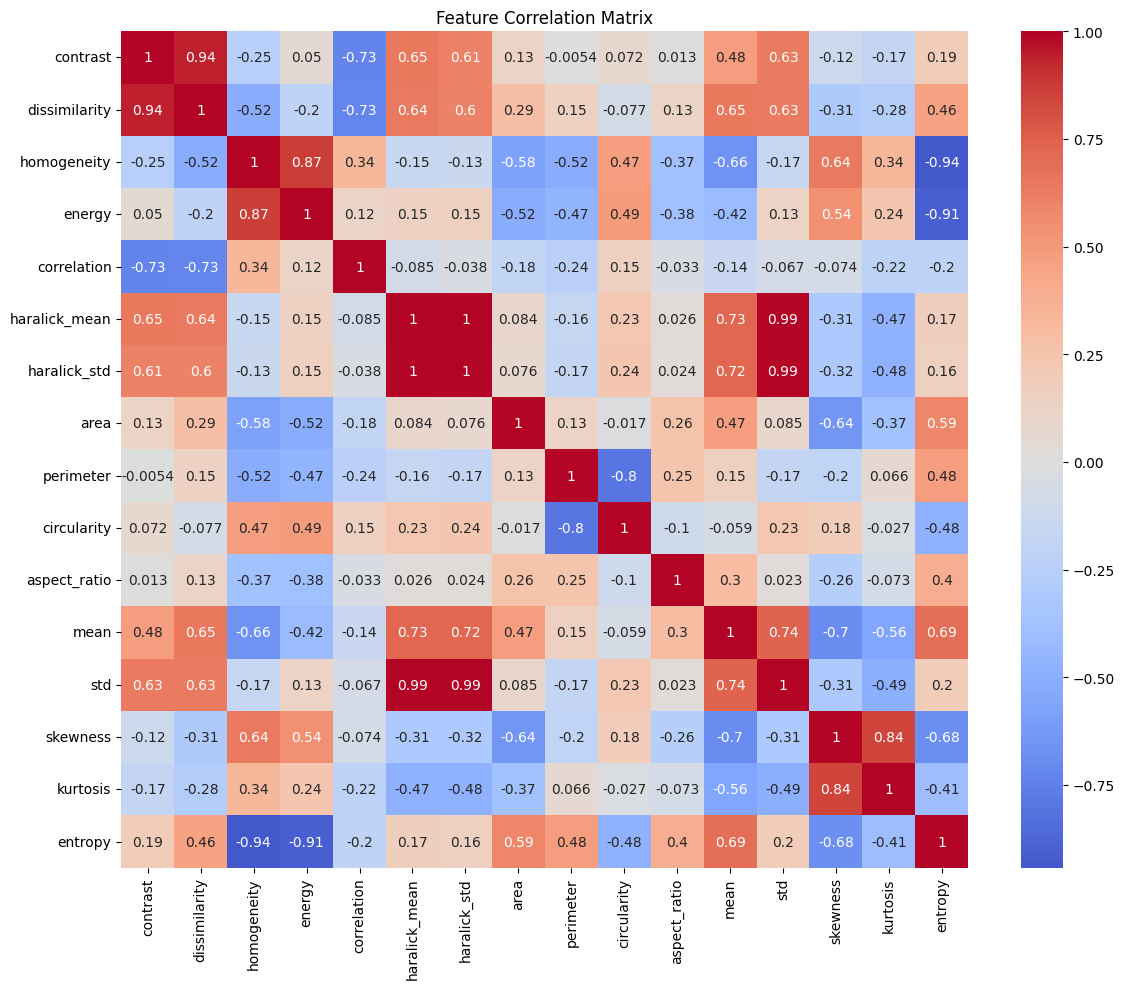


Plotting feature importance...


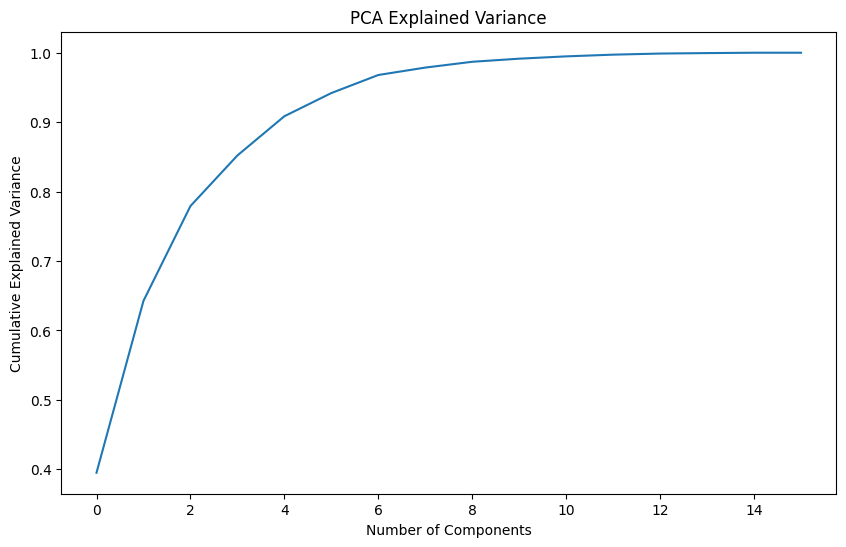

In [6]:

def plot_feature_correlations(features):
    """Plot feature correlation matrix"""
    plt.figure(figsize=(12, 10))
    sns.heatmap(features.corr(), annot=True, cmap='coolwarm', center=0)
    plt.title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.show()

def plot_feature_importance(features, labels):
    """Plot feature importance using PCA"""
    pca = PCA()
    pca.fit(features)
    
    plt.figure(figsize=(10, 6))
    plt.plot(np.cumsum(pca.explained_variance_ratio_))
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('PCA Explained Variance')
    plt.show()

# Plot feature correlations
print("Plotting feature correlations...")
plot_feature_correlations(X_train_scaled)

# Plot feature importance
print("\nPlotting feature importance...")
plot_feature_importance(X_train_scaled, y_train)

In [7]:
# Save processed features
print("Saving processed features...")
X_train_scaled.to_csv(os.path.join(PROCESSED_DATA_DIR, 'X_train_features.csv'), index=False)
X_test_scaled.to_csv(os.path.join(PROCESSED_DATA_DIR, 'X_test_features.csv'), index=False)

# Save labels
pd.Series(y_train).to_csv(os.path.join(PROCESSED_DATA_DIR, 'y_train.csv'), index=False)
pd.Series(y_test).to_csv(os.path.join(PROCESSED_DATA_DIR, 'y_test.csv'), index=False)

print("\nFeature extraction completed!")
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Test features shape: {X_test_scaled.shape}")

Saving processed features...

Feature extraction completed!
Training features shape: (5712, 16)
Test features shape: (1311, 16)
